# Photoswitching fingerprints: modulating bleaching rate

In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings

def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Data preparation

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=1, shape="triangle"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

irradiance=2.5
wavelength=640
bleaching=True
energy_transfer=True
reducing_agent="mea"
concentration=100
ph=7.5


In [3]:
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance,
    wavelength=wavelength,
    bleaching=bleaching,
    energy_transfer=energy_transfer,
    dstorm=True,
    dstorm_parameters={'reducing_agent':reducing_agent,
    'concentration':concentration,
    'ph':ph},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({5:2e4, 4:1e7})
transition_set.finalize()

In [4]:
transition_set.transition_df

transition_type abbreviation  \
Fluorophore identity                                                        
cy5_dna     0                      TransitionType.EXCITATION          EXC   
            1            TransitionType.FLUORESCENT_EMISSION          FLU   
            2         TransitionType.INTERSYSTEM_CROSSING_ST        ISCST   
            3         TransitionType.INTERSYSTEM_CROSSING_TS        ISCTS   
            4                   TransitionType.ISOMERIZATION          ISO   
            5                      TransitionType.PHOTO_BISO        PBISO   
            6                      TransitionType.THERM_BISO        TBISO   
            7           TransitionType.INTERNAL_CONVERSION_S          ICS   
            8                      TransitionType.ET_CYCLE_T          ETT   
            9                      TransitionType.ET_CYCLE_S          ETS   
            10                    TransitionType.REDUCTION_T         REDT   
            11                    TransitionType.REDUCTION_S         REDS   
            12                    TransitionType.OXIDATION_1         OXI1   
            13               TransitionType.PHOTOBLEACHING_1         BLE1   

                         initial_state       final_state          rate  \
Fluorophore identity                                                     
cy5_dna     0           SingleState.S0    SingleState.S1  7.269626e+06   
            1           SingleState.S1    SingleState.S0  1.588235e+08   
            2           SingleState.S1    SingleState.T1  8.300000e+05   
            3           SingleState.T1    SingleState.S0  5.000000e+03   
            4           SingleState.S1   SingleState.Cis  1.000000e+07   
            5          SingleState.Cis    SingleState.S0  2.000000e+04   
            6          SingleState.Cis    SingleState.S0  5.000000e+03   
            7           SingleState.S1    SingleState.S0  4.245818e+08   
            8           SingleState.T1    SingleState.S0  3.065343e+05   
            9           SingleState.S1    SingleState.S0  3.065343e+06   
            10          SingleState.T1  SingleState.OFF1  3.065343e+02   
            11          SingleState.S1  SingleState.OFF1  3.065343e+03   
            12        SingleState.OFF1    SingleState.S0  2.000000e-02   
            13          SingleState.T1     SingleState.B  1.000000e+01   

                      photon fluorophore_ids  absorbing  
Fluorophore identity                                     
cy5_dna     0          False             [0]      False  
            1           True             [0]      False  
            2          False             [0]      False  
            3          False             [0]      False  
            4          False             [0]      False  
            5          False             [0]      False  
            6          False             [0]      False  
            7          False             [0]      False  
            8          False             [0]      False  
            9          False             [0]      False  
            10         False             [0]      False  
            11         False             [0]      False  
            12         False             [0]      False  
            13         False             [0]       True

In [ ]:
rng = np.random.default_rng(1)

In [12]:
transition_set = transition_set.adjust_rates({13:1e1})
transition_set.finalize()
path = r"D:\simulation_data\bl_rate"
fingerprint_1e1, bl_times_1e1 = ro.fingerprint_analysis(transition_set, batches=1, 
batch_size=500, filepath=path, filename='bl_rate_1e1', seed=rng)

In [13]:
transition_set = transition_set.adjust_rates({13:1e2})
transition_set.finalize()
path = r"D:\simulation_data\bl_rate"
fingerprint_1e2, bl_times_1e2 = ro.fingerprint_analysis(transition_set, batches=1, 
batch_size=500, filepath=path, filename='bl_rate_1e2', seed=rng)

In [14]:
transition_set = transition_set.adjust_rates({13:1e3})
transition_set.finalize()
path = r"D:\simulation_data\bl_rate"
fingerprint_1e3, bl_times_1e3 = ro.fingerprint_analysis(transition_set, batches=3, 
batch_size=500, filepath=path, filename='bl_rate_1e3', seed=rng)

In [15]:
transition_set = transition_set.adjust_rates({13:1e4})
transition_set.finalize()
path = r"D:\simulation_data\bl_rate"
fingerprint_1e4, bl_times_1e4 = ro.fingerprint_analysis(transition_set, batches=30, 
batch_size=500, filepath=path, filename='bl_rate_1e4', seed=rng)

### Reading the data

In [2]:
identifiers = ['1e1', '1e2', '1e3', '1e4']
bleaching_times_all = []
fingerprints_all = []
fingerprints_discard = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    fingerprints_discard.append(pd.Series(np.zeros(299001), 
                                      np.round(np.linspace(1, 300, 299001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"D:\simulation_data\bl_rate"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                fingerprints_discard[identifiers.index(id)] += pd.read_parquet(file).iloc[1000:].sum(axis=1)
                break

for i, (fingerprint, fingerprint_discard) in enumerate(zip(fingerprints_all, fingerprints_discard)):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint
    fingerprint_discard = fingerprint_discard.cumsum() / fingerprint_discard.sum()
    fingerprints_discard[i] = fingerprint_discard

### Fitting the data

##### Using the fingerprints and fitting a CDF

In [3]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf = []
for fingerprint in fingerprints_all:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf.append([param.value for param in result.params.values()])

##### Using the bleaching times and fitting a PDF

In [26]:
parameters_all_fit_pdf = []
for bl_times in bleaching_times_all:
    pi, lambda1, lambda2 = dist.estimate_mixture_parameters(
        data=bl_times[:, 0][~np.isnan(bl_times[:, 0])],
        initial_guess=[0.5, 1, 1.1],
        bounds=([0, 1], [0, None], [0, None]),
        truncation_low=0,
        truncation_up=300,
        number_no_events=np.count_nonzero(np.isnan(bl_times[:, 0])),
        method='powell', 
    )
    parameters_all_fit_pdf.append([pi, lambda1, lambda2])

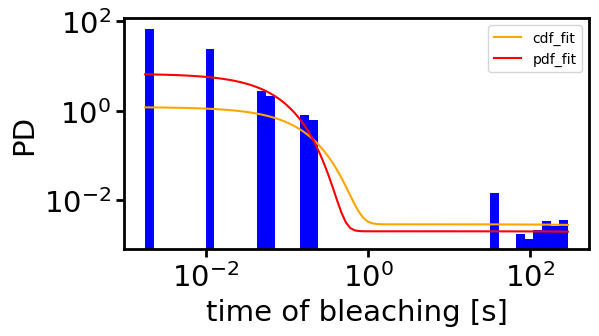

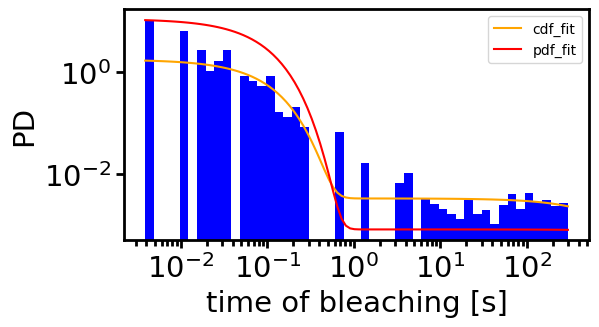

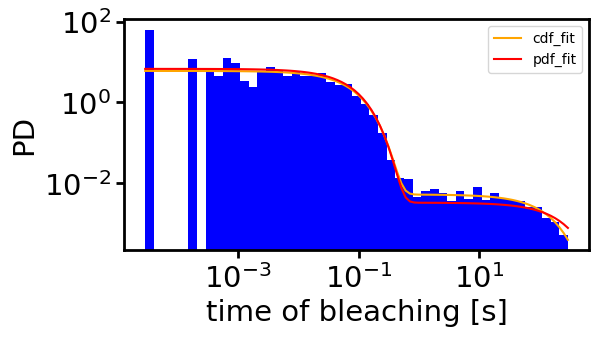

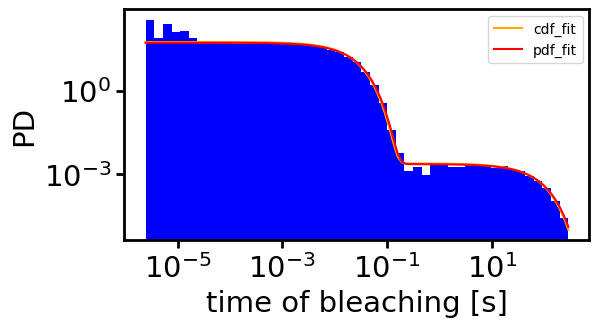

In [353]:
for (bl_times, parameters_1, parameters_2) in zip(bleaching_times_all, parameters_all_fit_pdf, parameters_all_fit_cdf):
    pi_fit_1, lambda1_fit_1, lambda2_fit_1 = parameters_1
    pi_fit_2, lambda1_fit_2, lambda2_fit_2 = parameters_2
    data = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
    bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
    ax = fi.universal_figure(type_='hist', bins=bins, data=data, density=True) 
    x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 100)
    fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_2, lambda2_fit_2, pi_fit_2)], 
                        axes=ax[0], color='orange', label='cdf_fit')
    fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_1, lambda2_fit_1, pi_fit_1)], 
                        type_='line', axes=ax[0], yscale='log', xscale='log', 
                        xlabel='time of bleaching [s]', ylabel='PD', color='red', label='pdf_fit', legend=True)

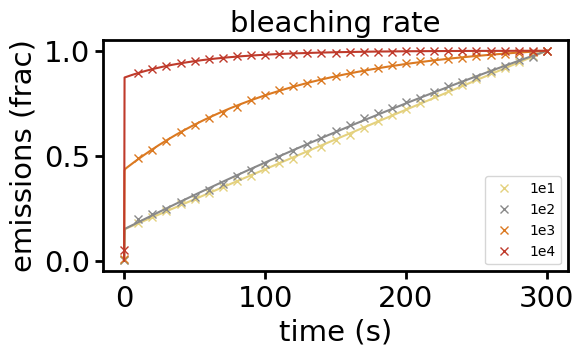

In [4]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_all_fit_cdf, labels, colors):
    pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='emissions (frac)', xlabel='time (s)', legend=True, axes=ax[0])
fig = mi.get_figure(ax)
fig.savefig("bl_rate_1.svg")

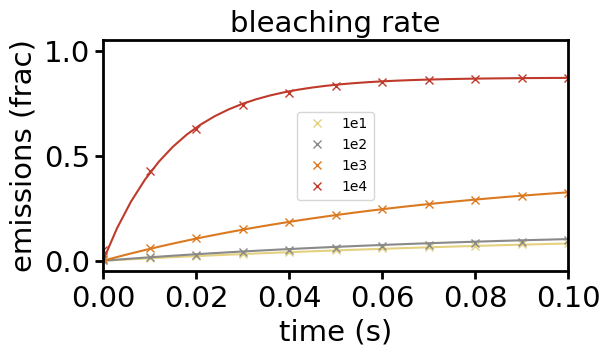

In [5]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 100000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_all_fit_cdf, labels, colors):
    pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10], fingerprint[::10]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10], fingerprint[::10]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='emissions (frac)', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 0.1])
fig = mi.get_figure(ax)
fig.savefig("bl_rate_2.svg")

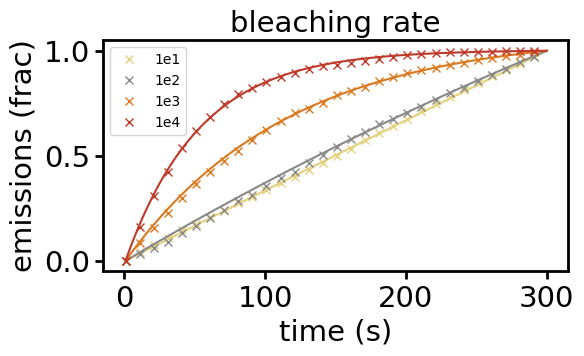

In [6]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(1, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_discard, parameters_all_fit_cdf, labels, colors):
    pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='emissions (frac)', xlabel='time (s)', legend=True, axes=ax[0])
fig = mi.get_figure(ax)
fig.savefig("bl_rate_3.svg")

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

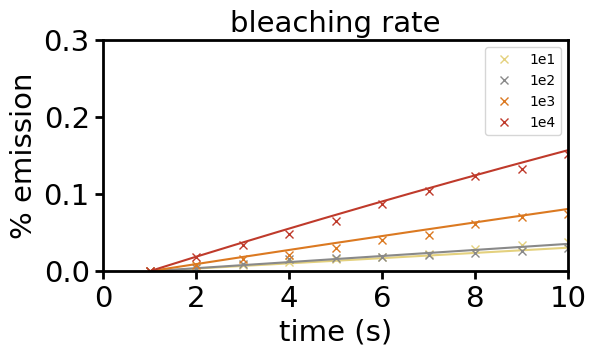

In [361]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(1, 300, 100000)
for (fingerprint, parameters, label, color) in zip(fingerprints_discard, parameters_all_fit_cdf, labels, colors):
    pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::1000], fingerprint[::1000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::1000], fingerprint[::1000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 10], ylim=[0, 0.3])